In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy


from scipy.optimize import curve_fit

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11-11.1.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk110 = pickle.load(f)
print("shotnoise", Pk110.attrs["shotnoise"])

shotnoise 286.3949289238728


In [4]:
import colossus.cosmology
from colossus.lss import bias as colossus_bias
cosmo = colossus.cosmology.cosmology.setCosmology("planck15")

bias_model = "sheth01"

z=1.5
bias0 = colossus_bias.haloBias(10**11, model=bias_model, z=z)
print(bias0)
bias0 = colossus_bias.haloBias(10**11.1, model=bias_model, z=z)
print(bias0)

bias_model = "comparat17"

z=1.5
bias0 = colossus_bias.haloBias(10**11, model=bias_model, z=z)
print(bias0)
bias0 = colossus_bias.haloBias(10**11.1, model=bias_model, z=z)
print(bias0)

1.254501032663919
1.2930499593363445
1.137078274795876
1.1740098587964916


In [330]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='EisensteinHu')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [300]:
def kernel_lin(ks, R=1, nbins=100):
    dx = 2*R
    results = []
    r = np.linspace(0, dx, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [301]:
def kernel_NL(ks, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(0, dx, nbins)
    xi = cf_nl(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [580]:
def kernel_new(ks, xi, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(1e-4, dx, nbins)
    xi = correlation_function(ks, Plin(ks),r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [588]:
xi = correlation_function(k, p,r)

In [583]:
kern =kernel_new(k, xi)

(-10.0, 5.0)

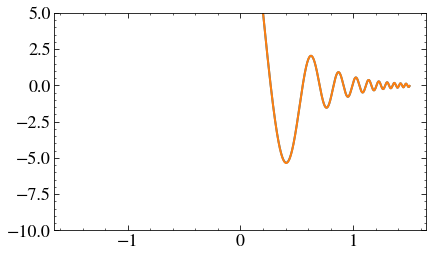

In [592]:
plt.plot(np.log10(k),kern)
plt.plot(np.log10(k),kernel_lin(k))
plt.ylim(-10,5)

In [591]:
kern/kernel_lin(k)

array([0.99754711, 0.99754715, 0.9975472 , ..., 1.16326125, 1.16615669,
       1.16914587])

In [548]:
def correlation_function(k_values, power_spectrum_values, r_values):
    xi_values = np.zeros_like(r_values)
    dk = k_values[1] - k_values[0]
    
    for i, r in enumerate(r_values):
        integral = np.sum(power_spectrum_values * np.sin(k_values * r) / (k_values * r) * k_values**2 * dk)
        xi_values[i] = integral / (2 * np.pi**2)
    
    return xi_values

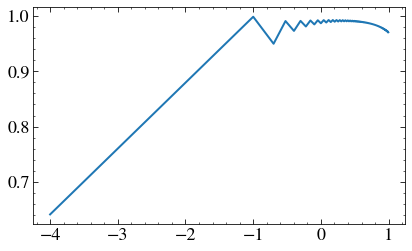

In [590]:
r = np.arange(1e-4,10,0.1)
k = np.linspace(10**-1.5, 10**1.5, 10000)

p = Plin(k)
plt.plot(np.log10(r),xi/cf_lin(r))
#plt.plot(r,cf_lin(r))

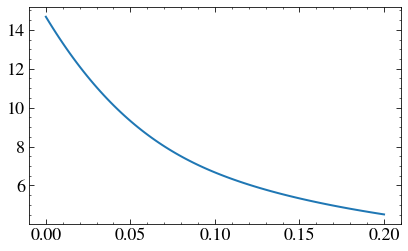

In [8]:
R=0.1
dx=2*R
nbins=100
r = np.linspace(0, dx, nbins)
xi = cf_lin(r)
plt.plot(r, xi)

In [9]:
def W_R(k, R=1):
    R = 2*R
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [10]:
def V_excl(R=1):
    R = 2*R
    return (4*np.pi*R**3)/3

In [11]:
def pk_random(k, R):
    result2 = -V_excl(R)*W_R(k,R)
    return result2

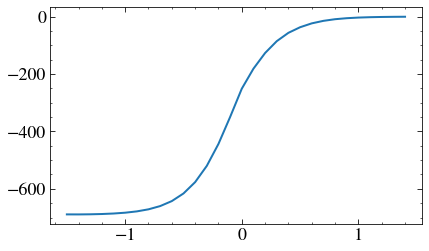

In [493]:
from scipy.signal import fftconvolve
conv = fftconvolve(W_R(10**logks1, R=0.1),Plin(10**logks1), mode="same")
plt.plot(logks1, -V_excl(R=0.1)*conv)

In [ ]:
from astropy.convolution import convolve, convolve_fft
image = Plin(10**logks1)
kernel = W_R(10**logks1, R=0.1)
result = convolve(image, kernel)

3729.8097861969018
113799.18622255727


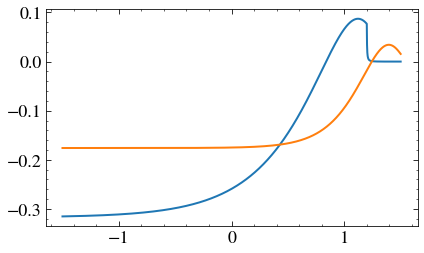

In [573]:
#logks1 = np.arange(-1.5, 1.5,0.01)
k = np.linspace(10**-1.5, 10**1.5, 10000)
logks1 = np.log10(k)
#conv = np.convolve(W_R(10**logks1, R=0.1),Plin(10**logks1), mode="same")/(len(logks)*2*np.pi**3)
output_normalization_factor = np.sum(10**logks)
w = W_R(10**logks1, R=0.1)
p = Plin(10**logks1)
print(np.sum(W_R(10**logks1, R=0.1)))
sum1 = np.sum(W_R(10**logks1, R=0.1))
sum2 = np.sum(Plin(10**logks1))
print(sum2)
conv = np.convolve(W_R(10**logks1, R=0.1),Plin(10**logks1), mode="same")

plt.plot(logks1, -V_excl(R=0.1)*conv/sum1)
plt.plot(logks1,-kernel_lin(10**logks1, R=0.1))

In [534]:
import scipy.fftpack

# Define the power spectrum P(k) (example values)
k = 10**logks1
P_k = p  # Example: Gaussian power spectrum
top_hat_window = w
# Define the top hat window in spatial domain (example length)
L = len(top_hat_window)  # Length of the top hat window

top_hat_window = np.pad(top_hat_window, (0, len(k) - L), 'constant')
top_hat_window /= np.sum(top_hat_window)
# Fourier transform of the top hat window (sinc function)
top_hat_fft = np.fft.fft(top_hat_window)
top_hat_fft = np.fft.fftshift(top_hat_fft)  # Shift zero frequency component to the center


In [535]:
# Perform convolution using np.convolve
convolution_result = np.convolve(P_k, top_hat_window, mode='same')


In [536]:
# Compute Fourier transform of P(k)
P_k_fft = np.fft.fft(P_k)
P_k_fft = np.fft.fftshift(P_k_fft)  # Shift zero frequency component to the center

# Perform pointwise multiplication in the frequency domain
product_fft = P_k_fft * top_hat_fft

# Compute the inverse Fourier transform to get the convolution result
ifft_result = np.fft.ifftshift(product_fft)  # Shift back the zero frequency component
ifft_result = np.fft.ifft(ifft_result).real
ifft_result /= np.sum(top_hat_window)


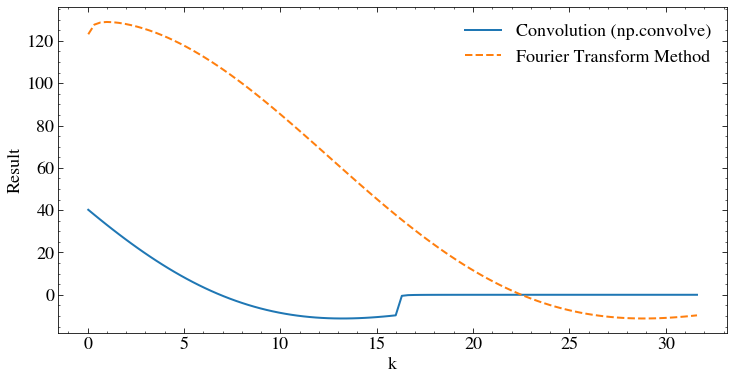

In [537]:
import matplotlib.pyplot as plt

# Plot the results for comparison
plt.figure(figsize=(12, 6))
plt.plot(k, convolution_result, label='Convolution (np.convolve)')
plt.plot(k, ifft_result, label='Fourier Transform Method', linestyle='dashed')
plt.xlabel('k')
plt.ylabel('Result')
plt.legend()
plt.show()


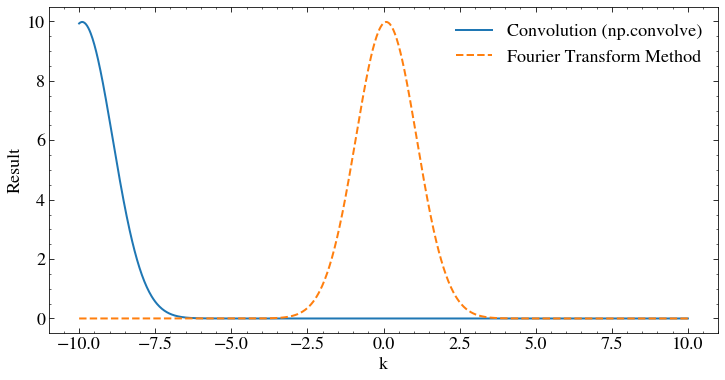

In [538]:
import numpy as np
import scipy.fftpack

# Define the power spectrum P(k) (example values)
k = np.linspace(-10, 10, 1000)
P_k = np.exp(-0.5 * k**2)  # Example: Gaussian power spectrum

# Define the top hat window in spatial domain (example length)
L = 10  # Length of the top hat window
top_hat_window = np.ones(L)
top_hat_window = np.pad(top_hat_window, (0, len(k) - L), 'constant')

# Fourier transform of the top hat window (sinc function)
top_hat_fft = np.fft.fft(top_hat_window)
top_hat_fft = np.fft.fftshift(top_hat_fft)  # Shift zero frequency component to the center


# Perform convolution using np.convolve
convolution_result = np.convolve(P_k, top_hat_window, mode='same')

# Compute Fourier transform of P(k)
P_k_fft = np.fft.fft(P_k)
P_k_fft = np.fft.fftshift(P_k_fft)  # Shift zero frequency component to the center

# Perform pointwise multiplication in the frequency domain
product_fft = P_k_fft * top_hat_fft

# Compute the inverse Fourier transform to get the convolution result
ifft_result = np.fft.ifftshift(product_fft)  # Shift back the zero frequency component
ifft_result = np.fft.ifft(ifft_result).real

import matplotlib.pyplot as plt

# Plot the results for comparison
plt.figure(figsize=(12, 6))
plt.plot(k, convolution_result, label='Convolution (np.convolve)')
plt.plot(k, ifft_result, label='Fourier Transform Method', linestyle='dashed')
plt.xlabel('k')
plt.ylabel('Result')
plt.legend()
plt.show()


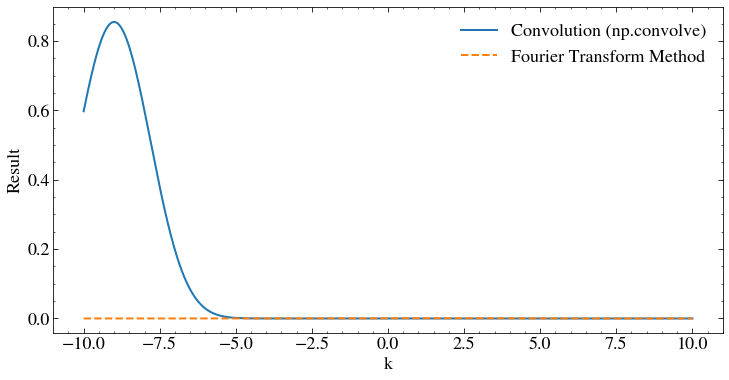

In [539]:
import numpy as np
import matplotlib.pyplot as plt

# Define the power spectrum P(k) (example values)
k = np.linspace(-10, 10, 1000)
P_k = np.exp(-0.5 * k**2)  # Example: Gaussian power spectrum

# Define the top hat window in spatial domain (example length)
L = 100  # Length of the top hat window (adjust as needed)
top_hat_window = np.ones(L)
top_hat_window = np.pad(top_hat_window, (0, len(k) - L), 'constant')

# Normalize the top hat window
top_hat_window /= np.sum(top_hat_window)

# Perform convolution using np.convolve
convolution_result = np.convolve(P_k, top_hat_window, mode='same')


# Compute Fourier transform of P(k)
P_k_fft = np.fft.fft(P_k)
top_hat_fft = np.fft.fft(top_hat_window)

# Perform pointwise multiplication in the frequency domain
product_fft = P_k_fft * top_hat_fft

# Compute the inverse Fourier transform to get the convolution result
ifft_result = np.fft.ifft(product_fft).real

# Normalize the inverse FFT result by the length of the signal
ifft_result /= len(k)

# Plot the results for comparison
plt.figure(figsize=(12, 6))
plt.plot(k, convolution_result, label='Convolution (np.convolve)')
plt.plot(k, ifft_result, label='Fourier Transform Method', linestyle='dashed')
plt.xlabel('k')
plt.ylabel('Result')
plt.legend()
plt.show()


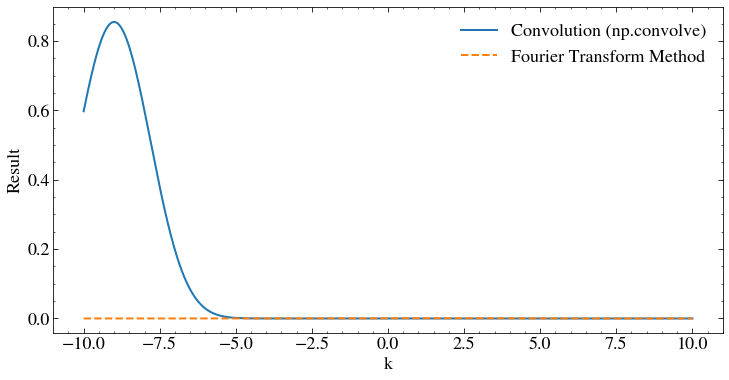

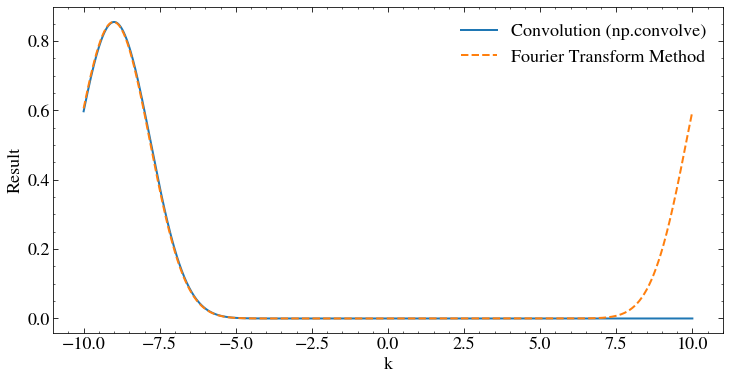

In [546]:
import numpy as np
import matplotlib.pyplot as plt

# Define the power spectrum P(k) (example values)
k = np.linspace(-10, 10, 1000)
P_k = np.exp(-0.5 * k**2)  # Example: Gaussian power spectrum

# Define the top hat window in spatial domain (example length)
L = 100  # Length of the top hat window (adjust as needed)
top_hat_window = np.ones(L)
top_hat_window = np.pad(top_hat_window, (0, len(k) - L), 'constant')

# Normalize the top hat window
top_hat_window /= np.sum(top_hat_window)

# Perform convolution using np.convolve and normalize the result
convolution_result = np.convolve(P_k, top_hat_window, mode='same')

# Compute Fourier transform of P(k)
P_k_fft = np.fft.fft(P_k)

# Compute the Fourier transform of the top hat window
top_hat_fft = np.fft.fft(top_hat_window)

# Perform pointwise multiplication in the frequency domain
product_fft = P_k_fft * top_hat_fft

# Compute the inverse Fourier transform to get the convolution result
ifft_result = np.fft.ifft(product_fft).real

# Normalize the inverse FFT result by the sum of the top hat window
ifft_result /= np.sum(top_hat_window)

# Align the results to handle any shifts
ifft_result = np.fft.ifftshift(ifft_result)
ifft_result = np.roll(ifft_result, len(ifft_result)//2 - len(top_hat_window)//2)

# Plot the results for comparison
plt.figure(figsize=(12, 6))
plt.plot(k, convolution_result, label='Convolution (np.convolve)')
plt.plot(k, ifft_result, label='Fourier Transform Method', linestyle='dashed')
plt.xlabel('k')
plt.ylabel('Result')
plt.legend()
plt.show()


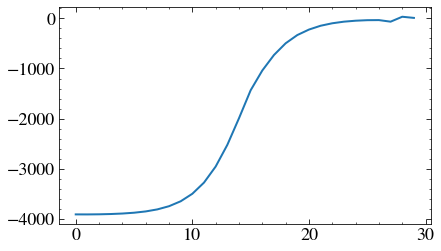

In [498]:
plt.plot(-V_excl(R=0.1)*conv/kernel_lin(10**logks1, R=0.1))

In [302]:
def fit_pow(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1, kernel_type="lin"):
    #bias_k = scale_dependent_bias(logk, a, b, c, d, logk0)
    bias_k = 1.2
    bias_factor = bias_k**2
    
    mask = logk > -0.3
    bias_factor_k = np.full(len(logk), bias_factor)
    #bias_factor_k[mask] = bias_factor*0.5
    #bias_factor_k = poly3(logk, *pop_fit1)

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        Pk = Plin(10**logk)
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        
        kernel = kernel_new(10**logk, R=R)
    elif kernel_type == "nl":
        Pk = Pnl(10**logk)
        kernel = kernel_NL(10**logk, R=R)
    
    result1 = bias_factor_k*Pk - bias_factor_k*kernel - V_excl(R)*W_R(10**logk, R)
    
    return result1

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

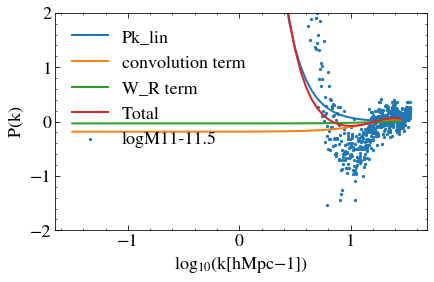

In [82]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.1
b_const = 1.1
b_factor = b_const**2
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Plin(10**logks), label="Pk_lin")
plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow(logks,R=R), label="Total")
plt.ylim(-1,500)
#plt.ylim(-5,15)
plt.ylim(-2,2)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

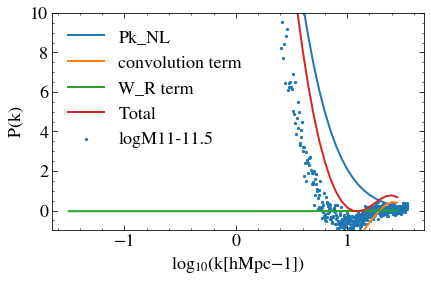

In [17]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.1
b_const = 1.15
b_factor = b_const**2

plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Pnl(10**logks), label="Pk_NL")
plt.plot(logks, -b_factor*kernel_NL(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow(logks,R=R, kernel_type="nl"), label="Total")
plt.ylim(-1,1)
plt.ylim(-1,10)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

In [293]:
plt.scatter(np.log10(Pk110["k"]),fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="nl")/(Pk110["power"].real-Pk110.attrs["shotnoise"]),s=1)
plt.scatter(np.log10(Pk110["k"]),fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin")/(Pk110["power"].real-Pk110.attrs["shotnoise"]),s=1)

plt.ylim(-0.5,5)
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.ylabel("fit/TNG")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

ValueError: results can only be computed up to k=1.04e+01 h/Mpc; try increasing the Cosmology parameter 'P_k_max'

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

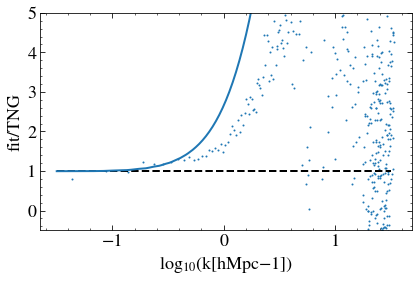

In [198]:
#plt.scatter(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"])/fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="nl"),s=1)
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")

plt.scatter(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"])/fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin"),s=1)

plt.ylim(-0.5,5)
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.ylabel("fit/TNG")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

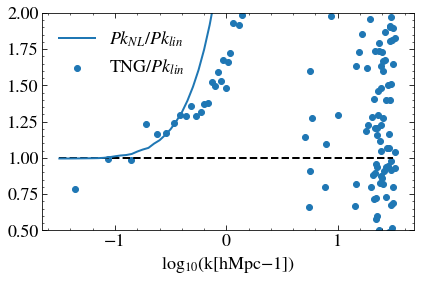

In [38]:
#ratio2[3] = Pnl(10**logk_tng[3])/Plin(10**logk_tng[3])
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")

ratio2 = (Pk110["power"].real-Pk110.attrs["shotnoise"])/(fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin")+ V_excl(R)*W_R(Pk110["k"], R))
ratio2 = (Pk110["power"].real-Pk110.attrs["shotnoise"])/(fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin"))

plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")

plt.ylim(0.5,2)
plt.legend(loc="upper left")
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

In [35]:
def poly3(x, a, b, c, d, x0):
    return a + b*(x-x0) + c*(x-x0)**2 + d*(x-x0)**3 

In [60]:

pop_fit1, pcov1 = curve_fit(poly3, np.log10(Pk110["k"][1:100]),ratio2[1:100],maxfev = 4000, sigma=None)
   

(0.0, 10.0)

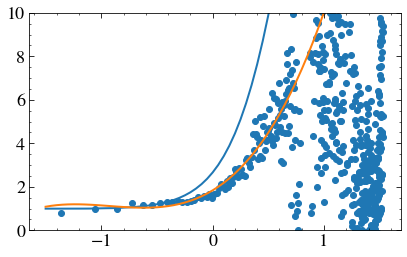

In [61]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="Pk_NL/Pk_lin")

plt.plot(logks, poly3(logks,*pop_fit1))
plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")

plt.ylim(0,10)

In [107]:
from colossus.cosmology import cosmology as colossus_cosmology
cosmo_colossus = colossus_cosmology.setCosmology(cosmo_name="planck15")
new_pk_colossus = cosmo_colossus.matterPowerSpectrum(k=10**logks,z=1.5, path="new_pk_lin.txt")
r_arr = np.arange(0.01, 1, 0.01)
cf_new = cosmo_colossus.correlationFunction(r_arr, z=1.5)

In [125]:

logks = np.arange(-1.5, 1.5, 0.01)
bias_fit = poly3(logks, *pop_fit1)
new_pk_lin = bias_fit*Plin(10**logks)

In [380]:

logks = np.arange(-4, 2, 0.001)
bias_fit = poly3(logks, *pop_fit1)
new_pk_lin = Plin(10**logks)

In [381]:
with open("new_pk_lin.txt", "w") as f:
    for i, logk in enumerate(logks):
        print(logk, np.log10(new_pk_lin[i]), file=f)

In [454]:

logks = np.arange(-4, 2, 0.001)
bias_fit = poly3(logks, *pop_fit1)
new_pk_nl = Pnl(10**logks)

In [455]:
with open("new_pk_nl.txt", "w") as f:
    for i, logk in enumerate(logks):
        print(logk, np.log10(new_pk_nl[i]), file=f)

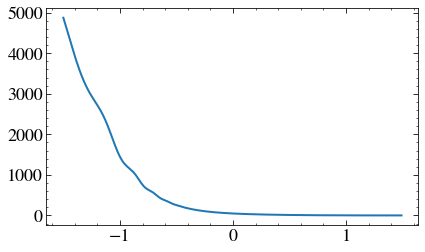

In [260]:
plt.plot(logks,new_pk_lin)

In [346]:
def kernel_new(ks, R=1, nbins=100):
    
    cosmo_colossus = colossus_cosmology.setCosmology("planck15", persistence = 'r')
    file_path = "./new_pk_lin.txt"
    ps_args_table = dict(model = 'mymodel', path = file_path )
    new_pk_colossus = cosmo_colossus.matterPowerSpectrum(10**logks, z=1.5, **ps_args_table)
    #new_pk_colossus = cosmo_colossus.matterPowerSpectrum(k=10**logks,z=1.5, path="new_pk_lin.txt")
    
    results = []
    dx = 2*R
    r = np.linspace(1e-3, dx, nbins)
    cf_new = cosmo_colossus.correlationFunction(r, z=1.5, ps_args=ps_args_table)
    xi = cf_new
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

(-1.0, 1.0)

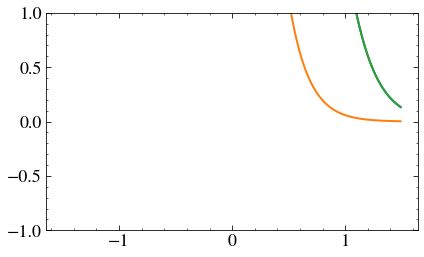

In [159]:
plt.plot(logks, new_pk_lin)

plt.plot(logks, Plin(10**logks))
plt.plot(logks, Pnl(10**logks))
plt.ylim(-1,1)

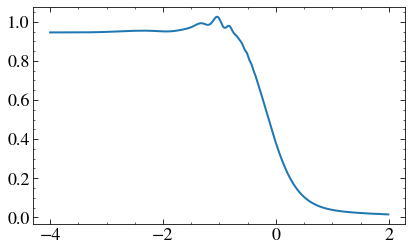

In [339]:
plt.plot(logks, new_pk_colossus/new_pk_lin)

In [437]:
logks1, logpks = np.loadtxt("new_pk_nl.txt", unpack=True)

[0.91499987 0.91499987 0.91499987 ... 0.91499987 0.91499987 0.91499987]


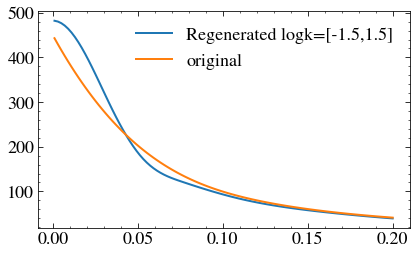

In [456]:
from colossus.utils import utilities
cosmo_colossus = colossus_cosmology.setCosmology("planck15", persistence = 'r')
file_path = "./new_pk_lin.txt"
ps_args_table = dict(model = 'mymodel', path = file_path )
new_pk_colossus = cosmo_colossus.matterPowerSpectrum(10**logks, z=1.5, **ps_args_table)


file_path = "./new_pk_nl.txt"
ps_args_table = dict(model = 'mymodel_nl', path = file_path )
new_pk_colossus_nl = cosmo_colossus.matterPowerSpectrum(10**logks, z=1.5, **ps_args_table)


pk_colossus = cosmo_colossus.matterPowerSpectrum(10**logks, z=1.5)

norm =new_pk_nl/new_pk_colossus_nl
print(new_pk_colossus_nl/new_pk_nl)

#P_eh98 = cosmo.matterPowerSpectrum(10**logks, model="camb", z=1.5)

#plt.plot(logks,new_pk_colossus/new_pk_lin)

#plt.plot(logks,new_pk_colossus)
#plt.plot(logks,pk_colossus)
#plt.plot(logks,new_pk_colossus_nl/new_pk_nl)
#plt.plot(logks,P_eh98)


#plt.plot(logks,new_pk_lin)
#plt.plot(logks,new_pk_nl)
#plt.plot(logks,10**logpks)

results = []
dx = 2*R
r = np.linspace(1e-3, dx, nbins)
cf_new = cosmo_colossus.correlationFunction(r, z=1.5, ps_args=ps_args_table)
plt.plot(r, cf_new, label="Regenerated logk=[-1.5,1.5]")
#plt.plot(r, cf_lin(r), label="original")
plt.plot(r, cf_nl(r),label="original")
plt.legend()
#plt.xlim(-1.5,1.5)
#plt.ylim(-10,10)

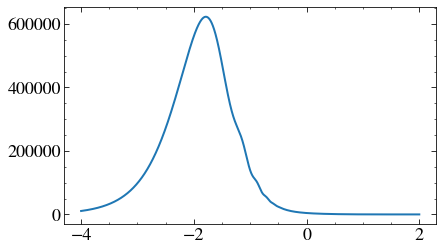

In [439]:
plt.plot(logks, 10**logpks)

In [418]:
cosmo_colossus = colossus_cosmology.setCosmology("planck15")
sigma8_cosmology = cosmo_colossus.sigma8

k_values = 10**logks
P_values = 10**logpks
# Function to calculate sigma8 from the power spectrum
def calculate_sigma8(k, Pk):
    R = 8.0  # Mpc/h
    integrand = lambda k: k**2 * Pk * (3 * (np.sin(k*R) - k*R*np.cos(k*R)) / (k*R)**3)**2
    sigma8_squared = scipy.integrate.quad(integrand, k.min(), k.max(), limit=1000)[0] / (2 * np.pi**2)
    return np.sqrt(sigma8_squared)

# Calculate sigma8 from the loaded power spectrum
sigma8_loaded = calculate_sigma8(k_values, P_values)

# Normalization factor
normalization_factor = (sigma8_cosmology / sigma8_loaded)**2

# Normalized power spectrum
P_values_normalized = P_values * normalization_factor

TypeError: only size-1 arrays can be converted to Python scalars

(-1.5, 1.5)

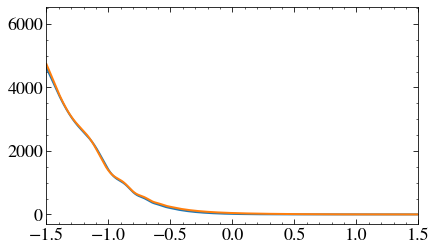

In [438]:
plt.plot(logks,new_pk_lin)
plt.plot(logks,new_pk_nl)
plt.xlim(-1.5,1.5)

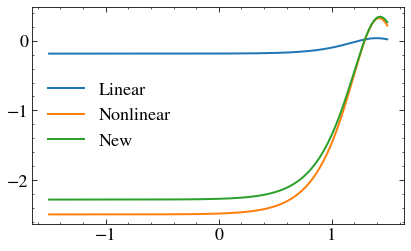

In [254]:
plt.plot(logks, -kernel_lin(10**logks, R=R), label="Linear")
plt.plot(logks, -kernel_NL(10**logks, R=R), label="Nonlinear")
plt.plot(logks, -kernel_new(10**logks, R=R), label="New")
plt.legend()

In [74]:
def fit_pow_new(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1, kernel_type="new"):
    #bias_k = scale_dependent_bias(logk, a, b, c, d, logk0)
    bias_k = 1.2
    bias_factor = bias_k**2
    
    # mask = logk > -0.3
    # bias_factor_k = np.full(len(logk), bias_factor)
    # #bias_factor_k[mask] = bias_factor*0.5
    # bias_factor_k = poly3(logk, *pop_fit1)

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        Pk = Plin(10**logk)
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        Pk = poly3(logk, *pop_fit1)*Plin(10**logk)
        kernel = kernel_new(10**logk, R=R)
    elif kernel_type == "nl":
        Pk = Pnl(10**logk)
        kernel = kernel_NL(10**logk, R=R)
    
    result1 = Pk - kernel - V_excl(R)*W_R(10**logk, R)
    
    return result1

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

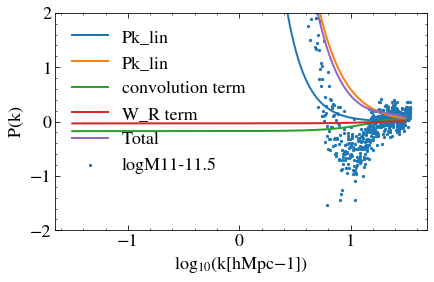

In [81]:
logks = np.arange(-1.5,1.5,0.01)
ks = 10**logks
R = 0.1
b_const = 1.1
b_factor = b_const**2
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Plin(10**logks), label="Pk_lin")
plt.plot(logks, new_pk_lin, label="Pk_lin")
plt.plot(logks, -kernel_new(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow_new(logks,R=R), label="Total")
plt.ylim(-1,500)
#plt.ylim(-5,15)
plt.ylim(-2,2)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")